In [1]:
import time
import pandas as pd
import numpy as np
from pathlib import Path
from math import prod
from time import perf_counter

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# -------------------------
# Helper: cari kolom (robust)
# -------------------------
def _find_col(df: pd.DataFrame, keywords):
    """Cari kolom yang mengandung semua keyword (case-insensitive)."""
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    for c in df.columns:
        c_low = str(c).lower()
        if all(k.lower() in c_low for k in keywords):
            return c
    return None

In [ ]:
file_path = 'FANP_100.xlsx' # Ganti dengan path ke file XLSX Anda di Google Drive
df = pd.read_excel(file_path)
print(df.head())

                       SCALE    L    M    U
0               Sama Penting  0.5  1.0  1.5
1      Sedikit Lebih Penting  1.0  1.5  2.0
2         Jauh Lebih Penting  1.5  2.0  2.5
3  Sangat Jauh Lebih Penting  2.0  2.5  3.0
4       Mutlak Lebih Penting  2.5  3.0  3.5


In [ ]:
# =========================
# 0. KONFIGURASI DASAR
# =========================

EXCEL_PATH = file_path # Menggunakan jalur yang sudah didefinisikan sebelumnya dari Google Drive
OUTPUT_PATH = "FANP_OUTPUT.xlsx"    # file hasil

# Asumsi struktur:
# - DE1: D1, D2, D3
# - DE2: D4, D5, D6
DETERMINANTS = ["DE1", "DE2"]
DIMENSIONS = ["D1", "D2", "D3", "D4", "D5", "D6"]

# mapping dimensi → enabler (sesuaikan kalau strukturmu beda)
DIM_TO_ENB = {
    "D1": ["E1", "E2"],
    "D2": ["E3", "E4"],
    "D3": ["E5", "E6"],
    "D4": ["E7", "E8"],
    "D5": ["E9", "E10"],
    "D6": ["E11", "E12"],
}

In [ ]:
# =========================
# 1. KELAS TFN & UTILITAS
# =========================

class TFN:
    def __init__(self, l, m, u):
        self.l = float(l)
        self.m = float(m)
        self.u = float(u)

    def __mul__(self, other):
        return TFN(self.l * other.l, self.m * other.m, self.u * other.u)

    def inv(self):
        return TFN(1.0 / self.u, 1.0 / self.m, 1.0 / self.l)

    def __add__(self, other):
        return TFN(self.l + other.l, self.m + other.m, self.u + other.u)

    def scalar_pow(self, s):
        # pangkat skalar positif, dipakai untuk geometric mean
        return TFN(self.l ** s, self.m ** s, self.u ** s)

    def defuzzify(self):
        # defuzzifikasi sederhana (rata-rata)
        return (self.l + self.m + self.u) / 3.0

    def __repr__(self):
        return f"TFN({self.l:.4f}, {self.m:.4f}, {self.u:.4f})"


def geometric_mean_tfn(tfn_list):
    """
    Geometric mean dari list TFN (rating-based agregasi).
    """
    n = len(tfn_list)
    l_prod = prod([t.l for t in tfn_list])
    m_prod = prod([t.m for t in tfn_list])
    u_prod = prod([t.u for t in tfn_list])
    return TFN(l_prod ** (1 / n), m_prod ** (1 / n), u_prod ** (1 / n))


def normalize_vector(vec):
    vec = np.array(vec, dtype=float)
    s = vec.sum()
    if s == 0:
        return vec
    return vec / s

# =========================
# 1B. CHANG EXTENT ANALYSIS (FSE) UTILITIES
# =========================
# Catatan:
# - Ini adalah inti metode Chang (synthetic extent + degree of possibility).
# - Dipakai untuk mengubah matriks pairwise fuzzy (TFN) -> bobot crisp.

def tfn_sum(tfn_list):
    """Penjumlahan TFN secara elemen."""
    l = sum(t.l for t in tfn_list)
    m = sum(t.m for t in tfn_list)
    u = sum(t.u for t in tfn_list)
    return TFN(l, m, u)


def degree_possibility(Si, Sk):
    """
    Degree of possibility V(Si >= Sk) untuk TFN (Chang, 1996).
    Si = (l1,m1,u1), Sk = (l2,m2,u2)

    Aturan:
    - jika m1 >= m2 -> 1
    - jika l2 >= u1 -> 0
    - selain itu -> (l2 - u1) / ((m1 - u1) - (m2 - l2))
    """
    l1, m1, u1 = Si.l, Si.m, Si.u
    l2, m2, u2 = Sk.l, Sk.m, Sk.u

    if m1 >= m2:
        return 1.0
    if l2 >= u1:
        return 0.0

    denom = (m1 - u1) - (m2 - l2)
    if abs(denom) < 1e-12:
        return 0.0

    val = (l2 - u1) / denom
    # clamp numerik
    return float(max(0.0, min(1.0, val)))


def chang_extent_weights(fuzzy_matrix):
    """
    Hitung bobot dengan metode Chang Extent Analysis dari matriks TFN n×n.

    Langkah:
    1) row_sum_i = Σ_j M_ij
    2) total_sum = Σ_i Σ_j M_ij  (bisa dari Σ row_sum_i)
    3) S_i = row_sum_i ⊗ (total_sum)^(-1)
    4) d_i = min_{k!=i} V(S_i >= S_k)
    5) w = normalisasi d
    """
    n = len(fuzzy_matrix)

    # 1) jumlah per baris
    row_sums = [tfn_sum(fuzzy_matrix[i]) for i in range(n)]

    # 2) jumlah total
    total_sum = tfn_sum(row_sums)

    # 3) synthetic extent
    inv_total = total_sum.inv()
    S = [row_sums[i] * inv_total for i in range(n)]

    # 4) degree of possibility -> d_i
    d = np.zeros(n, dtype=float)
    for i in range(n):
        vals = []
        for k in range(n):
            if i == k:
                continue
            vals.append(degree_possibility(S[i], S[k]))
        d[i] = min(vals) if vals else 1.0

    # 5) normalisasi
    w = normalize_vector(d)
    return w, S


# =========================
# 1C. BUILD FUZZY MATRIX (PAIRWISE RAW -> TFN MATRIX)
# =========================
def parse_pairwise_col(colname):
    """'D1_vs_D2' -> ('D1','D2')"""
    left, right = colname.split("_vs_")
    return left, right

def aggregate_tfn_from_column(df_raw, column_name, importance_map):
    """Ambil satu kolom linguistik, konversi ke TFN, lalu agregasi dengan geometric mean TFN."""
    tfn_list = []
    for val in df_raw[column_name].dropna():
        tfn_list.append(importance_map[val])
    if len(tfn_list) == 0:
        raise ValueError(f"Tidak ada data valid di kolom '{column_name}'.")
    return geometric_mean_tfn(tfn_list)

def build_fuzzy_matrix_from_pairwise_raw(df_raw, items, importance_map):
    """
    Bangun matriks fuzzy n×n dari sheet RAW berisi kolom-kolom pairwise seperti:
    'D1_vs_D2', 'D1_vs_D3', dst.
    Asumsi:
    - diagonal = (1,1,1)
    - jika ada kolom i_vs_j, maka M[i,j] = agg(TFN), M[j,i] = inverse
    """
    items = list(items)
    n = len(items)
    idx_map = {name: i for i, name in enumerate(items)}
    M = [[TFN(1, 1, 1) if i == j else None for j in range(n)] for i in range(n)]

    pair_cols = [c for c in df_raw.columns if c != "RESPONDEN" and "_vs_" in c]
    # isi yang tersedia
    for col in pair_cols:
        a, b = parse_pairwise_col(col)
        if a in idx_map and b in idx_map:
            t_ab = aggregate_tfn_from_column(df_raw, col, importance_map)
            i, j = idx_map[a], idx_map[b]
            M[i][j] = t_ab
            M[j][i] = t_ab.inv()

    # validasi kelengkapan (semua off-diagonal harus terisi)
    missing = []
    for i in range(n):
        for j in range(n):
            if i != j and M[i][j] is None:
                missing.append((items[i], items[j]))
    if missing:
        # biar errornya informatif, tampilkan beberapa saja
        sample = ", ".join([f"{a}>{b}" for a, b in missing[:8]])
        raise ValueError(
            f"Matriks pairwise untuk {items} belum lengkap. Contoh pasangan yang hilang: {sample}"
        )

    return M, pair_cols



In [ ]:
timing = {}
t0 = perf_counter()
# =========================
# 2. LOAD EXCEL & MAPPING
# =========================

xl = pd.ExcelFile(EXCEL_PATH)

scale_df = pd.read_excel(xl, "SCALE_MAP")
det_raw = pd.read_excel(xl, "DETERMINAN_RAW")
dim_raw = pd.read_excel(xl, "DIMENSION_RAW")
enb_raw = pd.read_excel(xl, "ENABLER_RAW")
inner_dep_raw = pd.read_excel(xl, "INNER_DEP_RAW")
ling_val_df = pd.read_excel(xl, "LINGUISTIC_VALUE")
enb_val_raw = pd.read_excel(xl, "ENABLER_VALUE_RAW")

# mapping skala kepentingan (Sama Penting, dst) → TFN
importance_map = {
    row["SCALE"]: TFN(row["L"], row["M"], row["U"])
    for _, row in scale_df.iterrows()
}

# mapping skala value (Sangat Tinggi, dst) → crisp
value_map = {
    row["LABEL_POSITIF"]: float(row["CRISP"])
    for _, row in ling_val_df.iterrows()
}
timing['load_excel'] = perf_counter() - t0


In [ ]:
# timing dict initialized in load cell


In [ ]:
t_core0 = perf_counter()
# =========================
# 3. BOBOT DETERMINAN (DE1, DE2) 2x2
# =========================

def compute_2x2_weights_from_raw(column_name, df_raw):
    """
    Ambil satu kolom pairwise (mis. 'DE1_vs_DE2' atau 'E1_vs_E2'),
    agregasi TFN dengan geometric mean, lalu hitung bobot 2 elemen.

    UPDATE (Chang Extent Analysis / FSE):
    - matriks 2x2 fuzzy dibangun dari t12 & inversnya
    - bobot dihitung menggunakan Chang Extent:
      S_i = (Σ_j M_ij) ⊗ (Σ_i Σ_j M_ij)^(-1)
      lalu degree of possibility V(S_i >= S_k), dan normalisasi.
    """
    # kumpulkan TFN dari semua responden
    tfn_list = []
    for val in df_raw[column_name].dropna():
        tfn_list.append(importance_map[val])

    # geometric mean TFN untuk perbandingan 1>2 (agregasi responden)
    t12 = geometric_mean_tfn(tfn_list)
    t21 = t12.inv()

    # bangun matriks 2x2 fuzzy
    fuzzy_matrix = [
        [TFN(1, 1, 1), t12],
        [t21, TFN(1, 1, 1)]
    ]

    # Chang Extent Analysis (FSE)
    w, S = chang_extent_weights(fuzzy_matrix)

    # w = [w1, w2]
    return w, t12  # kembalikan juga TFN utama kalau mau dicek


# DETERMINAN: asumsikan kolomnya 'DE1_vs_DE2'
det_weights, det_tfn = compute_2x2_weights_from_raw("DE1_vs_DE2", det_raw)
w_DE = pd.Series(det_weights, index=DETERMINANTS, name="w_DE")

print("Bobot Determinan (DE1, DE2):")
print(w_DE)
print()

# =========================
# 3B. INNER DEPENDENCE (JARINGAN DETERMINAN)
# =========================
# Catatan (sesuai diskusi):
# - Struktur Fuzzy Synthetic Extent (Chang) untuk jaringan individu determinan TIDAK diubah.
# - Setelah bobot lokal determinan (w_DE) didapat, kita tambahkan TFN inner dependence
#   khusus pada jaringan determinan (2x2), lalu:
#     1) defuzzify matriks inner dependence -> A (crisp)
#     2) kalikan A dengan vektor bobot determinan lokal (w_DE)
#     3) normalisasi hasilnya -> w_DE_inner

def _print_chang_details(label, S_list, item_labels=None):
    """Tampilkan S_i dan matriks V(Si>=Sj) untuk pelaporan degree of possibility."""
    n = len(S_list)
    if item_labels is None:
        item_labels = [f"S{i+1}" for i in range(n)]

    V = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            V[i, j] = 1.0 if i == j else degree_possibility(S_list[i], S_list[j])

    print(f"\n[{label}] Synthetic extent (S_i):")
    for nm, Si in zip(item_labels, S_list):
        print(f"  {nm} = {Si}")

    print(f"[{label}] Degree of Possibility V(Si >= Sj):")
    print(pd.DataFrame(V, index=item_labels, columns=item_labels))


# 3B-1) Dokumentasi degree of possibility untuk jaringan determinan LOKAL (tanpa mengubah hasil)
try:
    t12_local = det_tfn
    t21_local = det_tfn.inv()
    M_local = [
        [TFN(1, 1, 1), t12_local],
        [t21_local, TFN(1, 1, 1)]
    ]
    _, S_local = chang_extent_weights(M_local)
    _print_chang_details('DETERMINAN-LOKAL', S_local, item_labels=DETERMINANTS)
except Exception as e:
    print('Gagal menampilkan detail Chang determinan lokal:', e)


# 3B-2) Bangun matriks TFN inner dependence determinan dari sheet INNER_DEP_RAW
col_inner = None
if isinstance(inner_dep_raw, pd.DataFrame) and (not inner_dep_raw.empty):
    # kandidat nama kolom umum
    candidates = [
        'DE1_vs_DE2_INNER', 'DE1_vs_DE2_inner', 'DE1_vs_DE2_ID',
        'DE1_vs_DE2_DEP', 'DE1_vs_DE2',
    ]
    for cand in candidates:
        if cand in inner_dep_raw.columns:
            col_inner = cand
            break
    if col_inner is None:
        # fallback: cari kolom yang mengandung de1 & de2
        col_inner = _find_col(inner_dep_raw, ['de1', 'de2'])

if col_inner is None:
    print('\nInner dependence determinan: kolom tidak ditemukan di INNER_DEP_RAW. Menggunakan w_DE (tanpa inner dependence).')
    w_DE_inner = w_DE.copy()
else:
    print(f"\nInner dependence determinan menggunakan kolom: {col_inner}")

    # agregasi responden -> TFN (FGM hanya untuk agregasi)
    t12_id = aggregate_tfn_from_column(inner_dep_raw, col_inner, importance_map)
    t21_id = t12_id.inv()

    M_id = [
        [TFN(1, 1, 1), t12_id],
        [t21_id, TFN(1, 1, 1)]
    ]

    # dokumentasi degree of possibility untuk inner dependence
    try:
        _, S_id = chang_extent_weights(M_id)
        _print_chang_details('DETERMINAN-INNER', S_id, item_labels=DETERMINANTS)
    except Exception as e:
        print('Gagal menampilkan detail Chang inner dependence:', e)

    # defuzzify matriks inner dependence -> crisp matrix A
    A = np.array([[M_id[i][j].defuzzify() for j in range(2)] for i in range(2)], dtype=float)

    # kalikan dengan bobot determinan lokal (sudah normalisasi)
    w_vec = w_DE.values.astype(float)
    w_new = A.dot(w_vec)
    w_new = normalize_vector(w_new)

    w_DE_inner = pd.Series(w_new, index=DETERMINANTS, name='w_DE_inner')

print('\nBobot Determinan setelah inner dependence (w_DE_inner):')
print(w_DE_inner)
print()


Bobot Determinan (DE1, DE2):
DE1    0.846102
DE2    0.153898
Name: w_DE, dtype: float64


[DETERMINAN-LOKAL] Synthetic extent (S_i):
  DE1 = TFN(0.4355, 0.6381, 0.8971)
  DE2 = TFN(0.2819, 0.3619, 0.4969)
[DETERMINAN-LOKAL] Degree of Possibility V(Si >= Sj):
         DE1  DE2
DE1  1.00000  1.0
DE2  0.18189  1.0

Inner dependence determinan menggunakan kolom: DE1_to_DE2

[DETERMINAN-INNER] Synthetic extent (S_i):
  DE1 = TFN(0.3982, 0.6127, 0.8889)
  DE2 = TFN(0.2898, 0.3873, 0.5647)
[DETERMINAN-INNER] Degree of Possibility V(Si >= Sj):
          DE1  DE2
DE1  1.000000  1.0
DE2  0.424771  1.0

Bobot Determinan setelah inner dependence (w_DE_inner):
DE1    0.594884
DE2    0.405116
Name: w_DE_inner, dtype: float64



In [ ]:

# =========================
# 4. BOBOT DIMENSI (D1–D6) DIRECT RATING
# =========================


# =========================================================
# TAMBAHAN: helper untuk membangun matriks fuzzy dari rating
# (hanya untuk menampilkan FSE + DoP, TIDAK mengubah bobot)
# =========================================================

def _tfn_mul(a, b):
    """Perkalian TFN, kompatibel untuk beberapa implementasi class TFN."""
    try:
        return a * b
    except Exception:
        if hasattr(a, "mul"):
            return a.mul(b)
        raise

def _tfn_div(a, b):
    """Pembagian TFN: a ⊘ b = a ⊗ b^{-1}."""
    return _tfn_mul(a, b.inv())

def build_fuzzy_matrix_from_direct_ratings(tfns_dict, labels):
    """
    Bangun matriks fuzzy n×n dari TFN rating tiap item.
    M_ij = TFN_i ⊘ TFN_j (diag = 1).
    Dipakai hanya untuk pelaporan (FSE & DoP), bukan untuk bobot utama.
    """
    n = len(labels)
    M = [[None] * n for _ in range(n)]
    one = TFN(1, 1, 1)
    for i, li in enumerate(labels):
        for j, lj in enumerate(labels):
            if i == j:
                M[i][j] = one
            else:
                M[i][j] = _tfn_div(tfns_dict[li], tfns_dict[lj])
    return M


def compute_dimension_weights(dim_df, columns, by_cluster=None):
    """
    HITUNG BOBOT DIMENSI (auto):
    - Jika DIMENSION_RAW berisi kolom pairwise ('D1_vs_D2', dst) => gunakan Chang Extent Analysis (FSE).
    - Jika tidak (rating-based per dimensi) => gunakan Direct Fuzzy Rating (geometric mean per dimensi).

    Catatan:
    - FGM (geometric mean) tetap dipakai hanya untuk agregasi responden (mendapatkan TFN per entry).
    - Chang Extent (S_i + degree of possibility) dipakai pada tahap ekstraksi bobot dari matriks fuzzy.

    TAMBAHAN:
    - Untuk MODE 2 (rating-based), bobot tetap defuzzify+normalisasi (TIDAK diubah),
      namun ditambahkan output FSE + DoP diagnostik untuk pelaporan,
      dengan membangun matriks fuzzy dari rasio TFN rating: M_ij = TFN_i ⊘ TFN_j.
    """
    results = {}

    # deteksi apakah sheet ini pairwise atau rating-based
    pair_cols = [c for c in dim_df.columns if c != "RESPONDEN" and "_vs_" in c]

    # -------------------------
    # MODE 1: PAIRWISE (Chang Extent)
    # -------------------------
    if pair_cols:
        if by_cluster is None:
            clusters = {"ALL": list(columns)}
        else:
            clusters = by_cluster

        for cl, cols in clusters.items():
            # bangun matriks fuzzy n×n dari kolom pairwise yang relevan
            M, _ = build_fuzzy_matrix_from_pairwise_raw(dim_df, cols, importance_map)
            w, S = chang_extent_weights(M)
            results[cl] = pd.Series(w, index=cols, name=f"w_DIM_{cl}")
            _print_chang_details(f"DIMENSI-{cl}", S, item_labels=cols)
        return results

    # -------------------------
    # MODE 2: DIRECT FUZZY RATING (sesuai implementasi awal)
    # -------------------------
    if by_cluster is None:
        by_cluster = {"ALL": columns}

    for cl, cols in by_cluster.items():
        tfns = {}
        for c in cols:
            tfn_list = []
            for val in dim_df[c].dropna():
                tfn_list.append(importance_map[val])
            if len(tfn_list) == 0:
                raise ValueError(f"Tidak ada data valid untuk dimensi '{c}' pada cluster '{cl}'.")
            tfns[c] = geometric_mean_tfn(tfn_list)

        # defuzzify + normalisasi (rating-based)
        crisp = {k: v.defuzzify() for k, v in tfns.items()}
        w = normalize_vector(list(crisp.values()))
        results[cl] = pd.Series(w, index=list(crisp.keys()), name=f"w_DIM_{cl}")

        # -------------------------
        # TAMBAHAN: tampilkan FSE + DoP untuk rating-based (diagnostik)
        # (TIDAK mengubah bobot; hanya pelaporan)
        # -------------------------
        try:
            labels = list(crisp.keys())  # urutan sama dengan output bobot
            M_aux = build_fuzzy_matrix_from_direct_ratings(tfns, labels)
            _, S_aux = chang_extent_weights(M_aux)
            _print_chang_details(f"DIMENSI-{cl}-RATING-DIAG", S_aux, item_labels=labels)
        except Exception as e:
            print(f"[DIMENSI-{cl}-RATING-DIAG] Gagal menampilkan FSE/DoP diagnostik:", e)

    return results


# Asumsi:
# - D1, D2, D3 → di bawah DE1
# - D4, D5, D6 → di bawah DE2
dim_clusters = {
    "DE1": ["D1", "D2", "D3"],
    "DE2": ["D4", "D5", "D6"],
}

dim_weights_by_cluster = compute_dimension_weights(dim_raw, DIMENSIONS, dim_clusters)

print("Bobot Dimensi per Determinan:")
for cl, w in dim_weights_by_cluster.items():
    print(f"\nCluster {cl}:")
    print(w)
print()


[DIMENSI-DE1-RATING-DIAG] Synthetic extent (S_i):
  D1 = TFN(0.1438, 0.3219, 0.7180)
  D2 = TFN(0.1391, 0.3111, 0.6883)
  D3 = TFN(0.1634, 0.3670, 0.8346)
[DIMENSI-DE1-RATING-DIAG] Degree of Possibility V(Si >= Sj):
          D1   D2        D3
D1  1.000000  1.0  0.924841
D2  0.980522  1.0  0.903771
D3  1.000000  1.0  1.000000

[DIMENSI-DE2-RATING-DIAG] Synthetic extent (S_i):
  D4 = TFN(0.1384, 0.3166, 0.7172)
  D5 = TFN(0.1376, 0.3137, 0.7103)
  D6 = TFN(0.1613, 0.3697, 0.8592)
[DIMENSI-DE2-RATING-DIAG] Degree of Possibility V(Si >= Sj):
          D4   D5        D6
D4  1.000000  1.0  0.912862
D5  0.994962  1.0  0.907496
D6  1.000000  1.0  1.000000
Bobot Dimensi per Determinan:

Cluster DE1:
D1    0.321807
D2    0.310857
D3    0.367336
Name: w_DIM_DE1, dtype: float64

Cluster DE2:
D4    0.316273
D5    0.313624
D6    0.370103
Name: w_DIM_DE2, dtype: float64



In [ ]:
# =========================
# 5. BOBOT ENABLER (E1–E12) DARI PAIRWISE ENABLER_RAW
# =========================

def parse_enb_pair(colname):
    """
    'E1_vs_E2' → ('E1','E2')
    'E4_vs_E3' → ('E4','E3')
    """
    left, right = colname.split("_vs_")
    return left, right



def compute_enabler_weights_by_group(enb_df_raw, groups):
    """
    HITUNG BOBOT ENABLER (auto):
    - Jika untuk sebuah group tersedia kolom pairwise lengkap (Ei_vs_Ej untuk semua pasangan) => Chang Extent n×n.
    - Jika tidak lengkap, fallback ke pasangan 2×2 (pakai compute_2x2_weights_from_raw yang sudah Chang).
    groups: dict group_name -> list enabler IDs
    return: dict group_name -> pd.Series bobot lokal
    """
    results = {}
    all_pair_cols = [c for c in enb_df_raw.columns if c != "RESPONDEN" and "_vs_" in c]

    for gname, items in groups.items():
        # cek apakah kolom pairwise lengkap untuk group ini
        items = list(items)
        needed = set()
        for i in range(len(items)):
            for j in range(i+1, len(items)):
                needed.add(f"{items[i]}_vs_{items[j]}")
                needed.add(f"{items[j]}_vs_{items[i]}")
        available = set([c for c in all_pair_cols if parse_enb_pair(c)[0] in items and parse_enb_pair(c)[1] in items])

        # lengkap jika setiap pasangan ada minimal salah satu arahnya
        complete = True
        for i in range(len(items)):
            for j in range(i+1, len(items)):
                if (f"{items[i]}_vs_{items[j]}" not in all_pair_cols) and (f"{items[j]}_vs_{items[i]}" not in all_pair_cols):
                    complete = False
                    break
            if not complete:
                break

        if complete and len(items) >= 3:
            M, _ = build_fuzzy_matrix_from_pairwise_raw(enb_df_raw, items, importance_map)
            w, S = chang_extent_weights(M)
            results[gname] = pd.Series(w, index=items, name=f"w_ENB_{gname}")
            _print_chang_details(f"ENABLER-{gname}", S, item_labels=items)
        else:
            # fallback: jika group hanya 2 elemen, cukup ambil 1 kolom pairwise yang tersedia lalu hitung 2×2 (Chang)
            w_local = {}
            if len(items) == 2:
                a0, a1 = items[0], items[1]
                preferred = f"{a0}_vs_{a1}"
                alt = f"{a1}_vs_{a0}"
                if preferred in all_pair_cols:
                    col_use = preferred
                elif alt in all_pair_cols:
                    col_use = alt
                else:
                    raise ValueError(f"Tidak ditemukan kolom pairwise untuk pasangan {a0} dan {a1} pada group {gname}.")
                (a, b) = parse_enb_pair(col_use)
                weights, t12 = compute_2x2_weights_from_raw(col_use, enb_df_raw)
                w_local[a] = float(weights[0])
                w_local[b] = float(weights[1])
                # Pelaporan Chang (DoP) untuk enabler 2x2 (tanpa mengubah bobot)
                try:
                    M2 = [[TFN(1,1,1), t12], [t12.inv(), TFN(1,1,1)]]
                    _, S2 = chang_extent_weights(M2)
                    _print_chang_details(f"ENABLER-{gname}", S2, item_labels=[a, b])
                except Exception as e:
                    print('Gagal menampilkan detail Chang enabler 2x2:', e)
            else:
                # group >2 tapi data pairwise tidak lengkap: gabungkan pasangan yang ada (heuristik minimal)
                rel_cols = [c for c in all_pair_cols if parse_enb_pair(c)[0] in items and parse_enb_pair(c)[1] in items]
                if not rel_cols:
                    raise ValueError(f"Tidak ada kolom pairwise yang cocok untuk group {gname}.")
                # akumulasikan bobot sementara lalu rata-rata bila ada duplikasi
                acc = {it: [] for it in items}
                for col in rel_cols:
                    a, b = parse_enb_pair(col)
                    weights, _ = compute_2x2_weights_from_raw(col, enb_df_raw)
                    acc[a].append(float(weights[0]))
                    acc[b].append(float(weights[1]))
                for it, vals in acc.items():
                    if vals:
                        w_local[it] = float(np.mean(vals))
            results[gname] = pd.Series(w_local, name=f"w_ENB_{gname}").sort_index()

    return results
# =========================================================
# HITUNG BOBOT ENABLER PER JARINGAN DIMENSI (sesuai FANP)
# =========================================================
# Dalam struktur penelitian ini, setiap dimensi memiliki jaringan enabler sendiri (2×2).
# Jadi: bobot enabler dihitung PER-DIMENSI, lalu baru disintesis ke bobot global.

enb_groups = DIM_TO_ENB  # mapping dimensi -> list enabler

enb_weights_by_dim = compute_enabler_weights_by_group(enb_raw, enb_groups)

print("Bobot Lokal Enabler per Dimensi:")
for dim, w_ser in enb_weights_by_dim.items():
    print(f"\nJaringan {dim}:")
    print(w_ser)
print()

# Flatten agar kompatibel dengan pipeline global-weight yang sudah ada.
# (Tidak mengubah rumus global weight; hanya sumber bobot lokal enabler dibuat konsisten dengan jaringan.)
w_ENB_local = pd.concat(enb_weights_by_dim.values()).sort_index()
w_ENB_local.name = "w_ENB_local"

print("Bobot Lokal Enabler (E1–E12) - gabungan dari jaringan per-dimensi:")
print(w_ENB_local)
print()



[ENABLER-D1] Synthetic extent (S_i):
  E1 = TFN(0.4443, 0.6441, 0.8991)
  E2 = TFN(0.2795, 0.3559, 0.4825)
[ENABLER-D1] Degree of Possibility V(Si >= Sj):
          E1   E2
E1  1.000000  1.0
E2  0.117105  1.0

[ENABLER-D2] Synthetic extent (S_i):
  E4 = TFN(0.4505, 0.6508, 0.9062)
  E3 = TFN(0.2758, 0.3492, 0.4707)
[ENABLER-D2] Degree of Possibility V(Si >= Sj):
          E4   E3
E4  1.000000  1.0
E3  0.062779  1.0

[ENABLER-D3] Synthetic extent (S_i):
  E5 = TFN(0.4301, 0.6340, 0.8950)
  E6 = TFN(0.2835, 0.3660, 0.5063)
[ENABLER-D3] Degree of Possibility V(Si >= Sj):
         E5   E6
E5  1.00000  1.0
E6  0.22123  1.0

[ENABLER-D4] Synthetic extent (S_i):
  E7 = TFN(0.4818, 0.6755, 0.9207)
  E8 = TFN(0.2631, 0.3245, 0.4217)
[ENABLER-D4] Degree of Possibility V(Si >= Sj):
     E7   E8
E7  1.0  1.0
E8  0.0  1.0

[ENABLER-D5] Synthetic extent (S_i):
  E9 = TFN(0.4040, 0.6136, 0.8829)
  E10 = TFN(0.2911, 0.3864, 0.5557)
[ENABLER-D5] Degree of Possibility V(Si >= Sj):
           E9  E10
E9

In [ ]:
# =========================
# 6. BOBOT GLOBAL ENABLER (DE → DIM → ENB)
# =========================


# Gunakan bobot determinan yang mempertimbangkan inner dependence (khusus jaringan determinan)
# Jika inner dependence tidak tersedia, w_DE_inner akan sama dengan w_DE
w_DE_effective = w_DE_inner if 'w_DE_inner' in globals() else w_DE

# Siapkan bobot dimensi global dulu
w_DIM_global = {}

for det in DETERMINANTS:
    dim_list = dim_clusters[det]
    # bobot lokal dimensi di dalam determinan ini
    w_dim_local = dim_weights_by_cluster[det]
    for d in dim_list:
        # global = bobot DE * bobot dimensi lokal
        w_DIM_global[d] = w_DE_effective[det] * w_dim_local[d]

w_DIM_global = pd.Series(w_DIM_global, name="w_DIM_global").sort_index()

print("Bobot Global Dimensi:")
print(w_DIM_global)
print()

# Sekarang bobot global enabler
w_ENB_global = {}

for dim, enb_list in DIM_TO_ENB.items():
    for e in enb_list:
        w_ENB_global[e] = w_DIM_global[dim] * w_ENB_local[e]

w_ENB_global = pd.Series(w_ENB_global, name="w_ENB_global").sort_index()

print("Bobot Global Enabler (E1–E12):")
print(w_ENB_global)
print("Jumlah:", w_ENB_global.sum())
print()


Bobot Global Dimensi:
D1    0.191438
D2    0.184924
D3    0.218522
D4    0.128127
D5    0.127054
D6    0.149935
Name: w_DIM_global, dtype: float64

Bobot Global Enabler (E1–E12):
E1     0.171370
E10    0.036327
E11    0.127595
E12    0.022340
E2     0.020068
E3     0.010924
E4     0.174000
E5     0.178936
E6     0.039586
E7     0.128127
E8     0.000000
E9     0.090728
Name: w_ENB_global, dtype: float64
Jumlah: 1.0



In [ ]:
# =========================
# 7. NILAI VALUE PER ENABLER (DARI 100 RESPONDEN)
# =========================

def compute_value_per_enabler(enb_val_df, value_map):
    """
    Konversi SR/R/S/T/ST ke crisp, lalu rata-rata per enabler.
    """
    enb_cols = [c for c in enb_val_df.columns if c != "RESPONDEN"]
    v_mean = {}
    for c in enb_cols:
        vals = []
        for lab in enb_val_df[c].dropna():
            vals.append(value_map[lab])
        v_mean[c] = np.mean(vals)
    return pd.Series(v_mean, name="v_enb_mean").sort_index()

v_ENB = compute_value_per_enabler(enb_val_raw, value_map)

print("Nilai rata-rata crisp VALUE per Enabler (v_i):")
print(v_ENB)
print()

Nilai rata-rata crisp VALUE per Enabler (v_i):
E1     0.742
E10    0.518
E11    0.701
E12    0.663
E2     0.538
E3     0.577
E4     0.679
E5     0.601
E6     0.589
E7     0.766
E8     0.598
E9     0.496
Name: v_enb_mean, dtype: float64



In [ ]:
# Enabler bertipe NEGATIF (inhibitor)
NEGATIVE_ENABLERS = {"E2", "E7", "E8"}

# Pastikan v_ENB dalam bentuk DataFrame
if isinstance(v_ENB, pd.Series):
    v_ENB = pd.DataFrame({"value_crisp": v_ENB})

# Validasi kolom utama
if "value_crisp" not in v_ENB.columns:
    raise ValueError("v_ENB harus memiliki kolom 'value_crisp'")

# Buat kolom direction jika belum ada
if "direction" not in v_ENB.columns:
    v_ENB["direction"] = "positive"

# Terapkan label negatif
v_ENB.loc[v_ENB.index.isin(NEGATIVE_ENABLERS), "direction"] = "negative"

# Tampilkan hasil untuk verifikasi
print("=== SKALA LINGUISTIK VALUE (DIRECTION) ===")
print(v_ENB[["value_crisp", "direction"]].sort_index())

print("\n=== REKAP ===")
print(v_ENB["direction"].value_counts())


=== SKALA LINGUISTIK VALUE (DIRECTION) ===
     value_crisp direction
E1         0.742  positive
E10        0.518  positive
E11        0.701  positive
E12        0.663  positive
E2         0.538  negative
E3         0.577  positive
E4         0.679  positive
E5         0.601  positive
E6         0.589  positive
E7         0.766  negative
E8         0.598  negative
E9         0.496  positive

=== REKAP ===
direction
positive    9
negative    3
Name: count, dtype: int64


In [ ]:
# Sinkronisasi index
common_enb = w_ENB_global.index.intersection(v_ENB.index)
if len(common_enb) == 0:
    raise ValueError(
        "Index enabler tidak cocok antara 'w_ENB_global' dan 'v_ENB'. "
        "Pastikan keduanya pakai label yang sama (misal E1..E12)."
    )

# Ambil vektor bobot & nilai
w_vec = w_ENB_global.loc[common_enb].astype(float)
v_vec = v_ENB.loc[common_enb, "value_crisp"].astype(float)
direction_vec = v_ENB.loc[common_enb, "direction"]

# Detail FWA
fwa_detail = pd.DataFrame({
    "w_ENB_global": w_vec,
    "value_crisp": v_vec,
    "direction": direction_vec
})

fwa_detail["FWA_contrib"] = fwa_detail["w_ENB_global"] * fwa_detail["value_crisp"]

# Urutkan kontribusi
fwa_detail_sorted = fwa_detail.sort_values("FWA_contrib", ascending=False)

print("=== DETAIL FWA PER ENABLER (sebelum dijumlah) ===")
print(fwa_detail_sorted)
print()
rank_df = fwa_detail.copy()

# Total FWA
FWA_total = float(fwa_detail["FWA_contrib"].sum())
print("=== TOTAL FWA ===")
print("FWA_total =", FWA_total)

print("\n=== WAKTU KOMPUTASI ===")
for k, v in timing.items():
    print(f"{k:20s} : {v:.4f} detik")

print("\n=== TOTAL WAKTU KOMPUTASI (AKUMULATIF) ===")
print(f"TOTAL : {sum(timing.values()):.4f} detik")



=== DETAIL FWA PER ENABLER (sebelum dijumlah) ===
     w_ENB_global  value_crisp direction  FWA_contrib
E1       0.171370        0.742  positive     0.127156
E4       0.174000        0.679  positive     0.118146
E5       0.178936        0.601  positive     0.107540
E7       0.128127        0.766  negative     0.098145
E11      0.127595        0.701  positive     0.089444
E9       0.090728        0.496  positive     0.045001
E6       0.039586        0.589  positive     0.023316
E10      0.036327        0.518  positive     0.018817
E12      0.022340        0.663  positive     0.014811
E2       0.020068        0.538  negative     0.010797
E3       0.010924        0.577  positive     0.006303
E8       0.000000        0.598  negative     0.000000

=== TOTAL FWA ===
FWA_total = 0.6594776633877105

=== WAKTU KOMPUTASI ===
load_excel           : 0.0633 detik

=== TOTAL WAKTU KOMPUTASI (AKUMULATIF) ===
TOTAL : 0.0633 detik


In [ ]:
# =========================
# RANKING ENABLER
# =========================

rank_df = fwa_detail.copy()

# Ranking berdasarkan kontribusi (besar ke kecil)
rank_df["rank_FWA_contrib"] = rank_df["FWA_contrib"].rank(
    ascending=False, method="min"
).astype(int)

# Tampilkan ranking (urut menurut kontribusi)
rank_df_sorted = rank_df.sort_values("FWA_contrib", ascending=False)

print("\n=== RANKING ENABLER (berdasarkan FWA_contrib) ===")
print(rank_df_sorted[["w_ENB_global", "value_crisp", "direction", "FWA_contrib", "rank_FWA_contrib"]])

timing['core_fanp'] = perf_counter() - t_core0
print(f"\n=== TIMING (FAIR) ===\nLoad Excel (I/O+parse): {timing.get('load_excel', float('nan')):.6f} s\nCORE FANP (algoritma):  {timing['core_fanp']:.6f} s\nEND-TO-END (load+core): {(timing.get('load_excel', 0.0) + timing['core_fanp']):.6f} s\n")



=== RANKING ENABLER (berdasarkan FWA_contrib) ===
     w_ENB_global  value_crisp direction  FWA_contrib  rank_FWA_contrib
E1       0.171370        0.742  positive     0.127156                 1
E4       0.174000        0.679  positive     0.118146                 2
E5       0.178936        0.601  positive     0.107540                 3
E7       0.128127        0.766  negative     0.098145                 4
E11      0.127595        0.701  positive     0.089444                 5
E9       0.090728        0.496  positive     0.045001                 6
E6       0.039586        0.589  positive     0.023316                 7
E10      0.036327        0.518  positive     0.018817                 8
E12      0.022340        0.663  positive     0.014811                 9
E2       0.020068        0.538  negative     0.010797                10
E3       0.010924        0.577  positive     0.006303                11
E8       0.000000        0.598  negative     0.000000                12

=== TIMING (

In [ ]:
!pip install matplotlib



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ===============================
# TRAPEZOIDAL MEMBERSHIP FUNCTION
# ===============================
def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    mu = np.zeros_like(x)

    # Naik
    if b > a:
        idx = (x > a) & (x < b)
        mu[idx] = (x[idx] - a) / (b - a)

    # Datar
    idx = (x >= b) & (x <= c)
    mu[idx] = 1.0

    # Turun
    if d > c:
        idx = (x > c) & (x < d)
        mu[idx] = (d - x[idx]) / (d - c)

    return mu


# ==========================================
# DATA-DRIVEN QUARTILE PARAMETER (RETURN!)
# ==========================================
def build_trap_params_quartile(x_values):
    x = pd.Series(x_values).dropna().astype(float)

    xmin = float(x.min())
    q1   = float(x.quantile(0.25))
    q2   = float(x.quantile(0.50))
    q3   = float(x.quantile(0.75))
    xmax = float(x.max())

    return xmin, q1, q2, q3, xmax


# ===============================
# FUZZY 4 KATEGORI
# ===============================

# Basis fuzzy
xFWA = fwa_detail["FWA_contrib"].astype(float)

# Ambil parameter data-driven
xmin, q1, q2, q3, xmax = build_trap_params_quartile(xFWA)

# Definisi 4 kategori trapezoidal
params4 = {
    "Low": (xmin, xmin, q1, q2),
    "Moderate": (q1,  q1,  q2, q3),
    "High": (q2,  q2,  q3, xmax),
    "Highly":   (q3,  q3,  xmax, xmax),
}

# Hitung membership
mu4 = pd.DataFrame(index=fwa_detail.index)
for label, (a, b, c, d) in params4.items():
    mu4[label] = trapmf(xFWA.values, a, b, c, d)

# Label dominan
mu4["label_fuzzy"] = mu4.idxmax(axis=1)
mu4["mu_fuzzy"] = mu4.drop(columns=["label_fuzzy"]).max(axis=1)

# Tabel akhir
fuzzy_view_4 = pd.DataFrame({"FWA_contrib": xFWA}).join(mu4)
fuzzy_view_4 = fuzzy_view_4.sort_values("FWA_contrib", ascending=False)

# Output
print("=== PARAMETER DATA-DRIVEN (min, Q1, Q2, Q3, max) ===")
print((xmin, q1, q2, q3, xmax))

print("\n=== FWA → FUZZY MEMBERSHIP (4 KATEGORI) ===")
print(fuzzy_view_4)


=== PARAMETER DATA-DRIVEN (min, Q1, Q2, Q3, max) ===
(0.0, 0.013807767317890731, 0.03415855545278908, 0.10049420026241908, 0.1271562290238186)

=== FWA → FUZZY MEMBERSHIP (4 KATEGORI) ===
     FWA_contrib       Low  Moderate      High  Highly label_fuzzy  mu_fuzzy
E1      0.127156  0.000000  0.000000  0.000000     1.0      Highly       1.0
E4      0.118146  0.000000  0.000000  0.337934     1.0      Highly       1.0
E5      0.107540  0.000000  0.000000  0.735719     1.0      Highly       1.0
E7      0.098145  0.000000  0.035407  1.000000     0.0        High       1.0
E11     0.089444  0.000000  0.166582  1.000000     0.0        High       1.0
E9      0.045001  0.000000  0.836553  1.000000     0.0        High       1.0
E6      0.023316  0.532775  1.000000  0.000000     0.0    Moderate       1.0
E10     0.018817  0.753846  1.000000  0.000000     0.0    Moderate       1.0
E12     0.014811  0.950681  1.000000  0.000000     0.0    Moderate       1.0
E2      0.010797  1.000000  0.000000  0.00

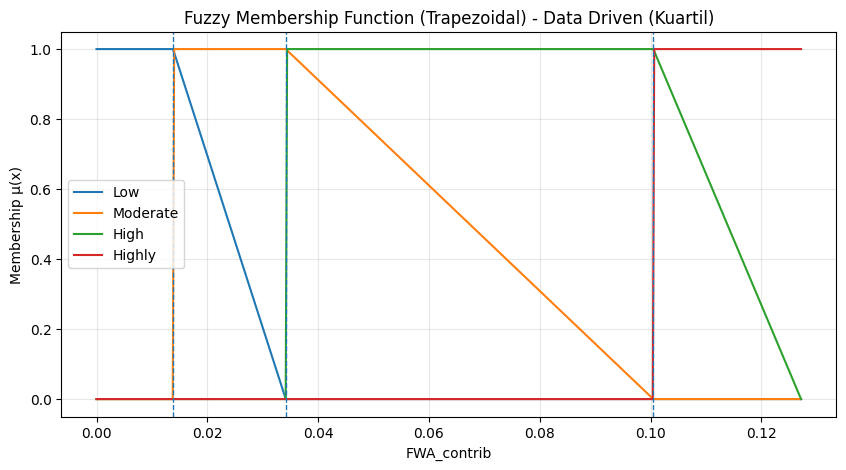

In [ ]:
# ===============================
# VISUALISASI MEMBERSHIP FUNCTIONS
# ===============================

# Grid untuk sumbu x (rentang nilai FWA_contrib)
x_min = float(xFWA.min())
x_max = float(xFWA.max())
x_grid = np.linspace(x_min, x_max, 500)

plt.figure(figsize=(10, 5))

for label, (a, b, c, d) in params4.items():
    mu_curve = trapmf(x_grid, a, b, c, d)
    plt.plot(x_grid, mu_curve, label=label)

# Garis batas kuartil (opsional, tapi bagus untuk laporan)
plt.axvline(q1, linestyle="--", linewidth=1)
plt.axvline(q2, linestyle="--", linewidth=1)
plt.axvline(q3, linestyle="--", linewidth=1)

plt.title("Fuzzy Membership Function (Trapezoidal) - Data Driven (Kuartil)")
plt.xlabel("FWA_contrib")
plt.ylabel("Membership μ(x)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


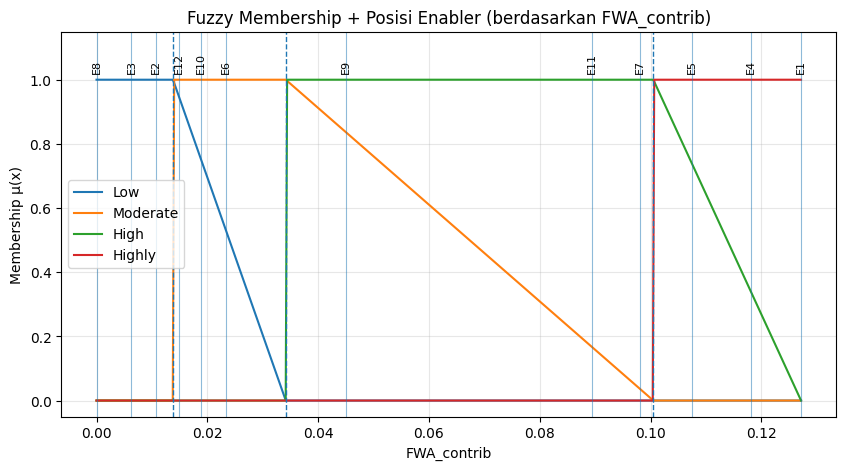

In [ ]:
# ===============================
# VISUALISASI + POSISI ENABLER
# ===============================

plt.figure(figsize=(10, 5))

# Kurva membership
for label, (a, b, c, d) in params4.items():
    plt.plot(x_grid, trapmf(x_grid, a, b, c, d), label=label)

# Garis vertikal posisi tiap enabler (FWA_contrib)
# (dengan label E1, E2, dst)
for enb, val in xFWA.items():
    plt.axvline(float(val), linewidth=0.8, alpha=0.5)
    plt.text(float(val), 1.02, str(enb), rotation=90, va="bottom", ha="center", fontsize=8)

# Kuartil
plt.axvline(q1, linestyle="--", linewidth=1)
plt.axvline(q2, linestyle="--", linewidth=1)
plt.axvline(q3, linestyle="--", linewidth=1)

plt.title("Fuzzy Membership + Enabler Position")
plt.xlabel("FWA_contrib")
plt.ylabel("Membership μ(x)")
plt.ylim(-0.05, 1.15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Uji Kompleksitas Empiris (Runtime) + Deteksi Memori (Peak)

Catatan:
- Ini **bukan** perhitungan Big-O secara formal; ini uji empiris untuk melihat **pola pertumbuhan waktu** saat jumlah responden ditambah.
- Pengukuran memori menggunakan `tracemalloc` untuk melihat **peak memory** selama fungsi berjalan.
- Sel ini **tidak mengubah** perhitungan utama; hanya menambahkan uji/diagnostik.


In [ ]:
import time
import tracemalloc

def _benchmark(fn, *args, warmup=1, repeat=5, **kwargs):
    '''
    Benchmark sederhana:
    - warmup: menjalankan fungsi beberapa kali agar stabil
    - repeat: jumlah pengulangan untuk estimasi waktu median
    Return: (median_seconds, peak_memory_mb, last_result)
    '''
    # Warmup (tanpa dicatat)
    for _ in range(max(0, warmup)):
        fn(*args, **kwargs)

    times = []
    last_result = None

    tracemalloc.start()
    for _ in range(max(1, repeat)):
        t0 = time.perf_counter()
        last_result = fn(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    median_s = float(pd.Series(times).median())
    peak_mb = float(peak) / (1024**2)
    return median_s, peak_mb, last_result


def run_value_pipeline_for_n_respondents(n, sample_mode="first", random_state=42):
    '''
    Menguji bagian pipeline yang bergantung pada jumlah responden:
    - Mengambil subset responden dari ENABLER_VALUE_RAW
    - Menghitung value rata-rata per enabler (crisp) via compute_value_per_enabler()
    '''
    df_val = enb_val_raw.copy()

    if "RESPONDEN" not in df_val.columns:
        raise ValueError("Sheet ENABLER_VALUE_RAW harus memiliki kolom 'RESPONDEN'.")

    unique_ids = df_val["RESPONDEN"].dropna().unique().tolist()
    if n > len(unique_ids):
        raise ValueError(f"n={n} melebihi jumlah responden tersedia ({len(unique_ids)}).")

    if sample_mode == "random":
        rng = np.random.default_rng(random_state)
        chosen = rng.choice(unique_ids, size=n, replace=False)
    else:
        chosen = unique_ids[:n]

    sub_df = df_val[df_val["RESPONDEN"].isin(chosen)].copy()

    v_series = compute_value_per_enabler(sub_df, value_map)
    v_df = v_series.to_frame("value_crisp")
    return v_df


# =========================
# JALANKAN UJI SKALA
# =========================
sizes = [10, 30, 50, 75, 100]  # ubah sesuai kebutuhan
results = []

for n in sizes:
    try:
        t_med, peak_mb, _ = _benchmark(run_value_pipeline_for_n_respondents, n)
        results.append({"n_responden": n, "median_time_s": t_med, "peak_mem_mb": peak_mb})
    except Exception as e:
        results.append({"n_responden": n, "median_time_s": None, "peak_mem_mb": None, "error": str(e)})

bench_df = pd.DataFrame(results)
bench_df


,n_responden,median_time_s,peak_mem_mb
0,10,0.009756,0.047905
1,30,0.007273,0.050261
2,50,0.006226,0.052529
3,75,0.007216,0.055831
4,100,0.007550,0.055831
